In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/final_cleaned_sulfate_data.csv')
display(df.head())

,Source Title,Cement_Type,SCM_Type,SCM_%,Exposure_Days,Sulfate_Exposure,Sulfate_Conc_mol/L,Comp_Strength_MPa,SCM_Sulfate_Interaction,Exposure_Period
0,Wang+et+al,Portland Cement,NaN,0,7,NaN,0.415,50.0,0.00,0-1m
1,Wang+et+al,Portland Cement,NaN,0,28,NaN,0.415,51.0,0.00,0-1m
2,Wang+et+al,Portland Cement,NaN,0,180,NaN,0.415,52.0,0.00,6-12m
3,Wang+et+al,Portland Cement,NaN,0,500,NaN,0.415,48.0,0.00,12-24m
4,Wang+et+al,Portland Cement,NS1,10,7,Sulfate,0.415,53.0,4.15,0-1m


In [ ]:
# Filter exposure days (keep only 7, 14, 28)
valid_days = [7, 14, 28, 56, 90]
df = df[df['Exposure_Days'].isin(valid_days)]

# Select only essential columns
keep_columns = [
    'SCM_%',
    'Exposure_Days',
    'Sulfate_Conc_mol/L',
    'SCM_Type',
    'Comp_Strength_MPa'  # Target
]
df = df[keep_columns]

# Verify
print(f"Final dataset size: {len(df)} samples")
print("Unique exposure days:", df['Exposure_Days'].unique())
print("SCM Types:", df['SCM_Type'].unique())

Final dataset size: 62 samples
Unique exposure days: [ 7 28 14 56 90]
SCM Types: [nan 'NS1' 'NS3' 'SF5' 'SF10' 'FA10' 'FA30' 'GBS10' 'GBS30' 'RHA' 'SF'
 'CPA']


In [ ]:
display(df.head())

,SCM_%,Exposure_Days,Sulfate_Conc_mol/L,SCM_Type,Comp_Strength_MPa,NaN
0,0,7,0.000,NaN,50.0,True
1,0,28,0.000,NaN,51.0,True
4,10,7,0.415,NS1,53.0,False
5,10,28,0.415,NS1,54.0,False
8,10,7,0.415,NS3,55.0,False


In [ ]:
# 2. Identify control samples (where Sulfate_Exposure is NaN)
df['NaN'] = df['SCM_Type'].isna()

# 3. FORCE sulfate concentration to 0 for controls
df.loc[df['NaN'], 'Sulfate_Conc_mol/L'] = 0.0

# 4. Verify
print("Control samples validation:")
print(df[df['NaN']][['SCM_Type', 'Sulfate_Conc_mol/L']].head())

# 5. Prepare features
X = df[['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L', 'NaN']]
y = df['Comp_Strength_MPa']

Control samples validation:
  SCM_Type  Sulfate_Conc_mol/L
0      NaN                 0.0
1      NaN                 0.0


In [ ]:
# Convert categorical SCM_Category
model_data = pd.get_dummies(df, columns=['SCM_Type'], drop_first=True)

# Final features/target
X = model_data.drop('Comp_Strength_MPa', axis=1)
y = model_data['Comp_Strength_MPa']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("\n=== Model Performance ===")
print(f"Training R²: {train_score:.3f}")
print(f"Test R²: {test_score:.3f}")
print(f"MAE: {mae:.2f} MPa")


=== Model Performance ===
Training R²: 0.986
Test R²: 0.976
MAE: 2.17 MPa


In [ ]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify split sizes
print(f"Training data size: {len(X_train)} samples")
print(f"Testing data size: {len(X_test)} samples")

Training data size: 49 samples
Testing data size: 13 samples


In [ ]:
# Interpret coefficients
coefficients = pd.Series(model.coef_, index=X.columns)
print("\n=== Feature Impacts ===")
print(coefficients.sort_values(ascending=False))


=== Feature Impacts ===
SCM_Type_RHA          33.782607
SCM_Type_SF           32.282607
SCM_Type_SF10         16.885124
SCM_Type_SF5          15.127502
SCM_Type_GBS10        10.627502
SCM_Type_NS3           8.885124
SCM_Type_FA10          7.127502
SCM_Type_NS1           7.127502
SCM_Type_GBS30         5.369880
SCM_Type_FA30          3.369880
Exposure_Days          0.024535
SCM_%                 -4.061433
NaN                  -70.089542
Sulfate_Conc_mol/L   -81.554432
dtype: float64


In [ ]:
display(df.head(30))

,SCM_%,Exposure_Days,Sulfate_Conc_mol/L,SCM_Type,Comp_Strength_MPa,NaN
0,0,7,0.000,NaN,50.00,True
1,0,28,0.000,NaN,51.00,True
4,10,7,0.415,NS1,53.00,False
5,10,28,0.415,NS1,54.00,False
8,10,7,0.415,NS3,55.00,False
9,10,28,0.415,NS3,56.00,False
12,10,7,0.415,SF5,60.00,False
13,10,28,0.415,SF5,63.00,False
16,10,7,0.415,SF10,63.00,False
17,10,28,0.415,SF10,66.00,False


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Load the dataset
df = pd.read_csv('/content/final_cleaned_sulfate_data.csv')

# Filter exposure days (keep only 7, 14, 28)
valid_days = [7, 14, 28, 56, 90]
df = df[df['Exposure_Days'].isin(valid_days)]

# Select only essential columns
keep_columns = [
    'SCM_%',
    'Exposure_Days',
    'Sulfate_Conc_mol/L',
    'SCM_Type',
    'Comp_Strength_MPa'  # Target
]
df = df[keep_columns]

# Identify control samples (where Sulfate_Exposure is NaN)
df['NaN'] = df['SCM_Type'].isna()

# FORCE sulfate concentration to 0 for controls
df.loc[df['NaN'], 'Sulfate_Conc_mol/L'] = 0.0

# Convert categorical SCM_Category
model_data = pd.get_dummies(df, columns=['SCM_Type'], drop_first=True)

# Final features/target
X = model_data.drop('Comp_Strength_MPa', axis=1)
y = model_data['Comp_Strength_MPa']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)


# Generate exposure days to predict (7,14,28,56,90,180)
prediction_days_cpa = [7, 14, 28, 56, 90, 180]

# Example: Predict for 20% CPA in 0.367M of sulfate
pred_data_cpa = pd.DataFrame({
    'SCM_%': [20] * len(prediction_days_cpa),
    'Exposure_Days': prediction_days_cpa,
    'Sulfate_Conc_mol/L': [0.367] * len(prediction_days_cpa)
})

# Prepare pred_data_cpa for prediction
# Add the 'NaN' column, set to False as these are not control samples
pred_data_cpa['NaN'] = False

# Create dummy variables for SCM_Type to match the training data
# Get all unique SCM_Type values from the original model_data
# Assuming model_data is available from previous steps
all_scm_types = model_data.columns[model_data.columns.str.startswith('SCM_Type_')]

# Initialize SCM_Type columns in pred_data_cpa with False
for col in all_scm_types:
    pred_data_cpa[col] = False

# Set the correct SCM_Type column to True for CPA
# Note: This assumes 'CPA' is one of the SCM_Type values the model was trained on
if 'SCM_Type_CPA' in pred_data_cpa.columns:
    pred_data_cpa['SCM_Type_CPA'] = True
else:
    # Handle the case where CPA was not in the training data's SCM_Type
    # This might require re-evaluating the prediction scenario or the training data
    print("Warning: 'CPA' was not found in the SCM_Type categories the model was trained on.")
    # Depending on the desired behavior, you might want to skip prediction or handle differently
    # For now, we'll proceed with the available columns, but the prediction might be inaccurate


# Ensure the order of columns in pred_data_cpa matches the training data (X_train)
# This is crucial for correct prediction
# Get the column order from the training data
train_cols = X_train.columns

# Reindex pred_data_cpa to match the training column order, filling missing columns with 0
pred_data_cpa = pred_data_cpa.reindex(columns=train_cols, fill_value=0)


# Make predictions
predictions_cpa = model.predict(pred_data_cpa)

# Display predictions
print("\nPredicted Comp_Strength (MPa) for 20% CPA in 0.367M Sulfate:")
for days, strength in zip(prediction_days_cpa, predictions_cpa):
    print(f"Exposure Days: {days}, Predicted Strength: {strength:.2f} MPa")


Predicted Comp_Strength (MPa) for 20% CPA in 0.367M Sulfate:
Exposure Days: 7, Predicted Strength: 9.42 MPa
Exposure Days: 14, Predicted Strength: 9.59 MPa
Exposure Days: 28, Predicted Strength: 9.93 MPa
Exposure Days: 56, Predicted Strength: 10.62 MPa
Exposure Days: 90, Predicted Strength: 11.45 MPa
Exposure Days: 180, Predicted Strength: 13.66 MPa


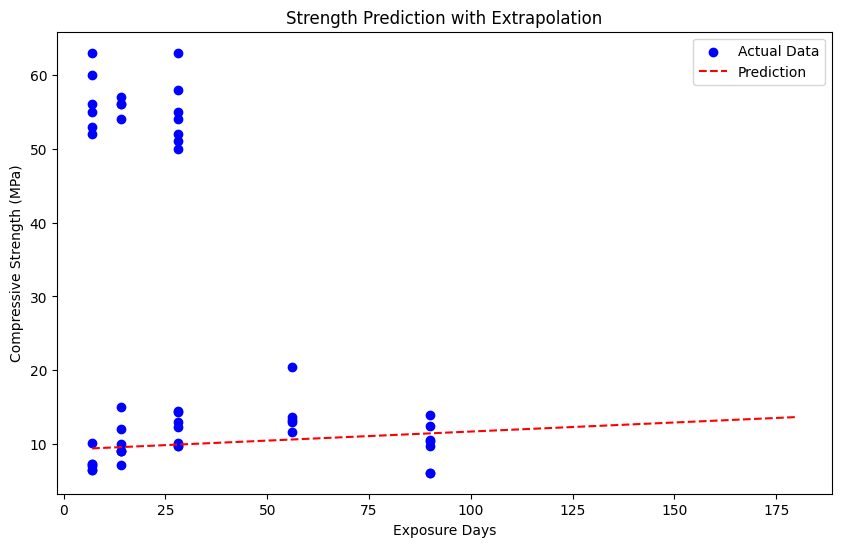

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(X_train['Exposure_Days'], y_train,
            c='blue', label='Actual Data')
plt.plot(pred_data_cpa['Exposure_Days'], predictions_cpa,
         'r--', label='Prediction')
# Removed code related to conf_interval as it was not defined.
# plt.fill_between(pred_data['Exposure_Days'],
#                  predictions - conf_interval,
#                  predictions + conf_interval,
#                  color='red', alpha=0.1)
plt.xlabel('Exposure Days')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Strength Prediction with Extrapolation')
plt.legend()
plt.show()

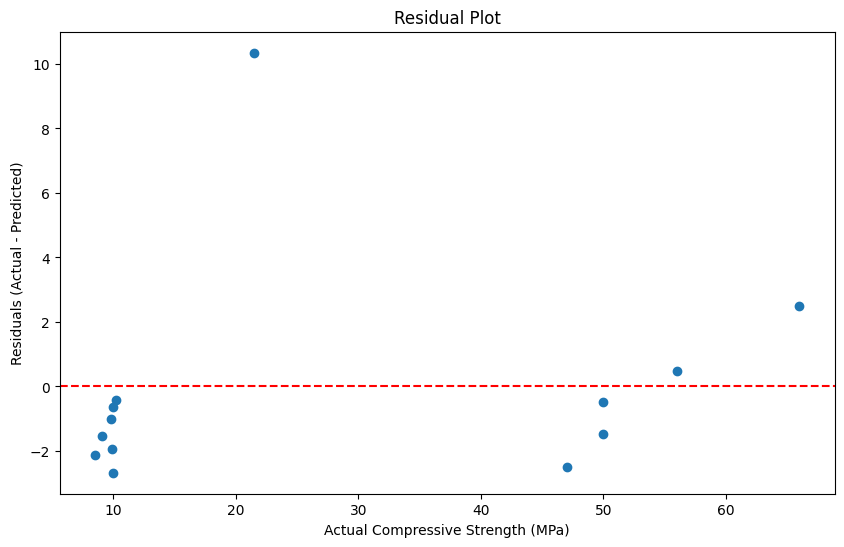

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Compressive Strength (MPa)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Evaluate on training and testing sets
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("\n=== Model Performance ===")
print(f"Training R²: {train_score:.3f}")
print(f"Test R²: {test_score:.3f}")
print(f"MAE: {mae:.2f} MPa")


=== Model Performance ===
Training R²: 0.982
Test R²: 0.972
MAE: 2.83 MPa


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/final_cleaned_sulfate_data.csv')

# Filter exposure days (keep only 7, 14, 28)
valid_days = [7, 14, 28, 56, 90]
df = df[df['Exposure_Days'].isin(valid_days)]

# Select only essential columns
keep_columns = [
    'SCM_%',
    'Exposure_Days',
    'Sulfate_Conc_mol/L',
    'SCM_Type',
    'Comp_Strength_MPa'  # Target
]
df = df[keep_columns]

# Identify control samples (where Sulfate_Exposure is NaN)
df['NaN'] = df['SCM_Type'].isna()

# FORCE sulfate concentration to 0 for controls
df.loc[df['NaN'], 'Sulfate_Conc_mol/L'] = 0.0


# Save the cleaned DataFrame to a new CSV file
output_path = '/content/cleaned_sulfate_data_for_model.csv'
df.to_csv(output_path, index=False)

print(f"Cleaned data saved to: {output_path}")

Cleaned data saved to: /content/cleaned_sulfate_data_for_model.csv


In [ ]:
# Display descriptive statistics for numerical columns
print("Descriptive Statistics:")
display(df.describe())

# Display information about the DataFrame (data types, non-null counts)
print("\nDataFrame Info:")
df.info()

Descriptive Statistics:


,SCM_%,Exposure_Days,Sulfate_Conc_mol/L,Comp_Strength_MPa
count,62.000000,62.000000,62.000000,62.000000
mean,16.129032,31.145161,0.384935,26.516129
std,5.538195,27.538258,0.110485,21.782645
min,0.000000,7.000000,0.000000,6.120000
25%,10.000000,7.000000,0.352000,9.747500
50%,20.000000,28.000000,0.367000,12.960000
75%,20.000000,49.000000,0.415000,52.000000
max,20.000000,90.000000,0.704000,66.000000



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 95
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SCM_%               62 non-null     int64  
 1   Exposure_Days       62 non-null     int64  
 2   Sulfate_Conc_mol/L  62 non-null     float64
 3   SCM_Type            60 non-null     object 
 4   Comp_Strength_MPa   62 non-null     float64
 5   NaN                 62 non-null     bool   
dtypes: bool(1), float64(2), int64(2), object(1)
memory usage: 3.0+ KB


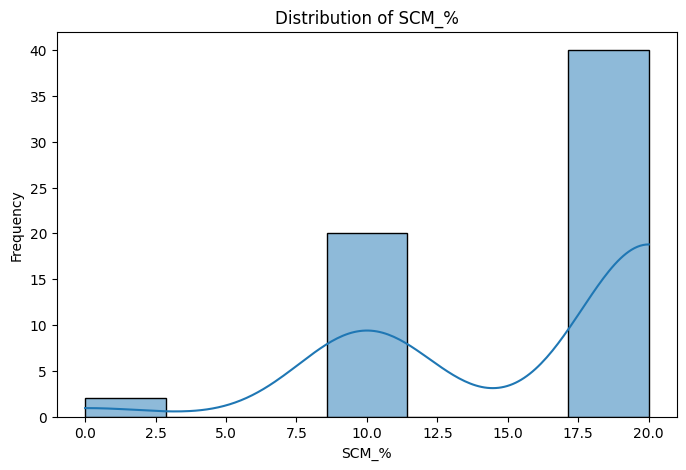

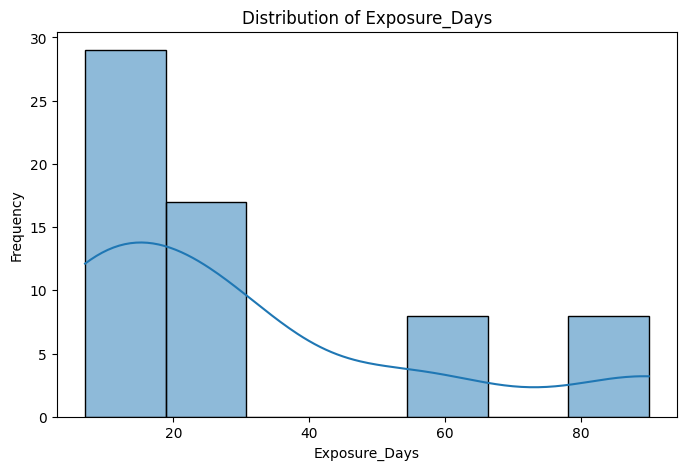

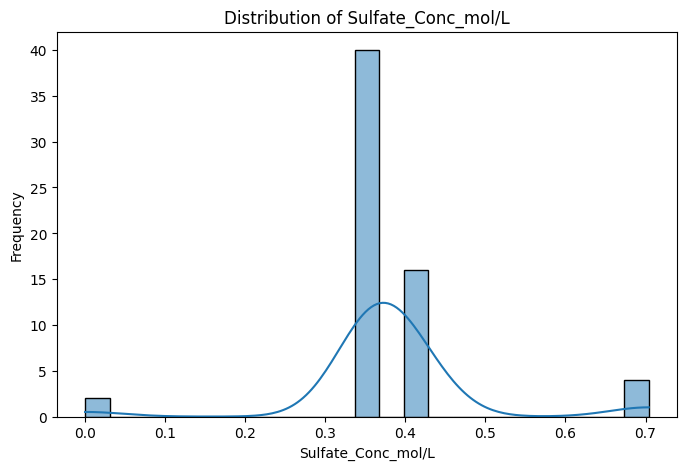

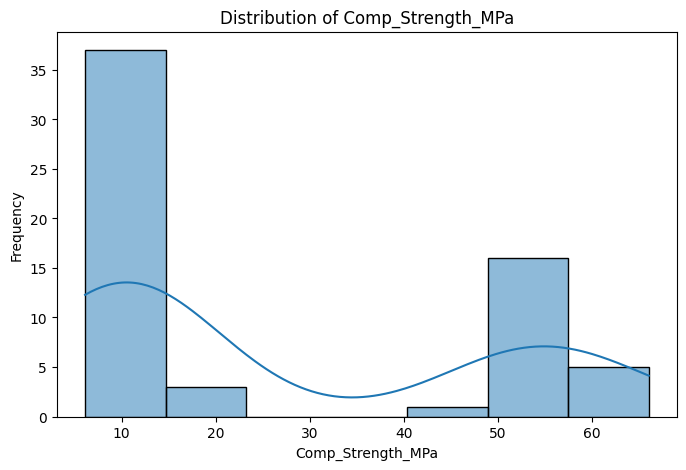

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numerical columns for plotting
numerical_cols = df.select_dtypes(include=np.number).columns

# Plot histograms for numerical columns
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

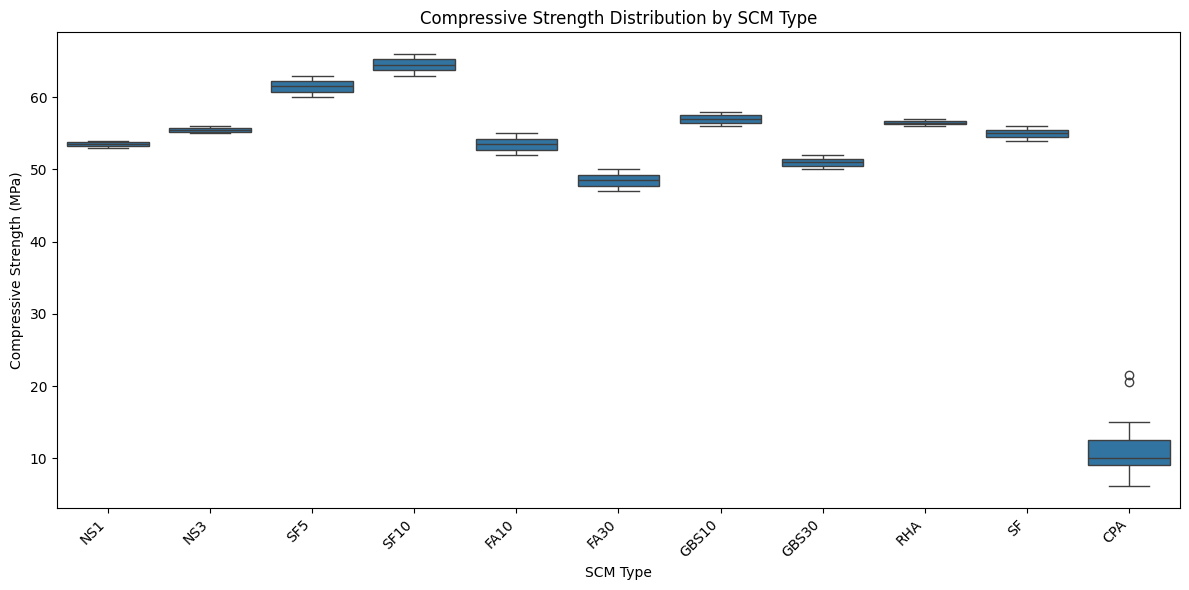

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='SCM_Type', y='Comp_Strength_MPa')
plt.title('Compressive Strength Distribution by SCM Type')
plt.xlabel('SCM Type')
plt.ylabel('Compressive Strength (MPa)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

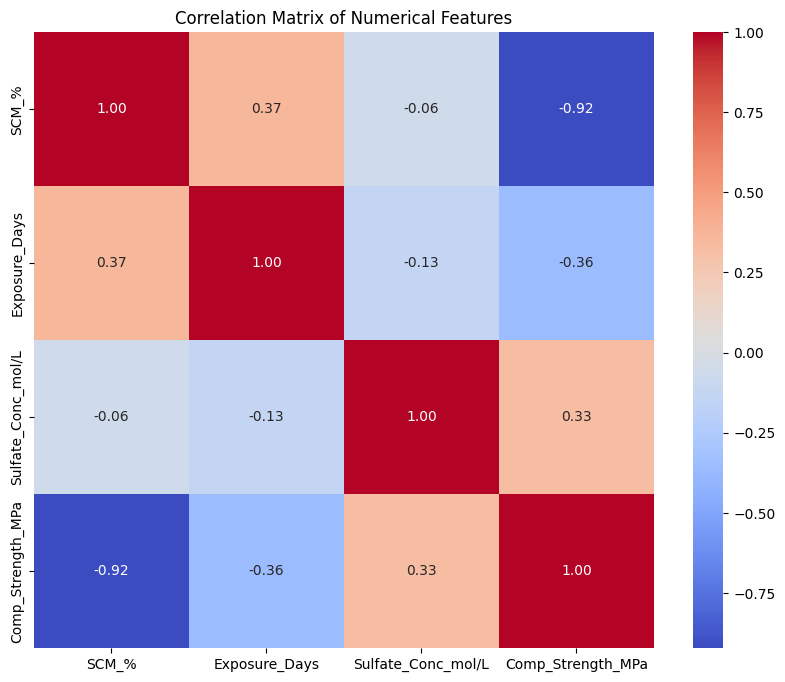

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numerical columns for correlation matrix
numerical_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import pandas as pd
import numpy as np

# Define the log transformation function, handling potential zero values if necessary
# A small constant (like 1) is often added to avoid log(0)
log_transformer = FunctionTransformer(func=lambda x: np.log(x + 1), validate=False)


# Preprocess: One-hot encode SCM_Type, standardize numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('log_exp_days', log_transformer, ['Exposure_Days']), # Apply log transformation to Exposure_Days
        ('num', StandardScaler(), ['SCM_%', 'Sulfate_Conc_mol/L']), # Standardize other numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['SCM_Type']) # One-hot encode SCM_Type
    ],
    remainder='passthrough' # Keep other columns (like 'NaN')
)


X = preprocessor.fit_transform(df.drop('Comp_Strength_MPa', axis=1))
y = df['Comp_Strength_MPa']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train MLR
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

Train R²: 0.9740444218282134
Test R²: 0.9703031607781604
MAE: 2.9271198824909725
RMSE: 3.9553331826337517


In [ ]:
# Get feature names after preprocessing
# Manually construct the list of feature names in the correct order
# Order: log_exp_days, num (standardized), cat (one-hot encoded), remainder (passthrough)

# Feature name from log_exp_days transformer
log_exp_day_feature = ['Exposure_Days']

# Feature names from num transformer (StandardScaler) - original names
num_features_scaled = ['SCM_%', 'Sulfate_Conc_mol/L']

# Feature names from cat transformer (OneHotEncoder)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(['SCM_Type'])

# Feature name from remainder='passthrough'
# Assuming 'NaN' is the only column passed through and it's the last one
passthrough_feature = ['NaN']


# Combine all feature names in the correct order
all_features = log_exp_day_feature + num_features_scaled + list(cat_feature_names) + passthrough_feature

# Display coefficients
coefficients = pd.DataFrame({
    'Feature': all_features,
    'Impact (MPa)': model.coef_
})
print(coefficients.sort_values('Impact (MPa)', ascending=False))

               Feature  Impact (MPa)
10        SCM_Type_RHA     25.509269
11         SCM_Type_SF     24.009269
12       SCM_Type_SF10      9.508695
13        SCM_Type_SF5      7.078733
6       SCM_Type_GBS10      2.578733
9         SCM_Type_NS3      1.508695
0        Exposure_Days      1.444203
4        SCM_Type_FA10     -0.921267
8         SCM_Type_NS1     -0.921267
7       SCM_Type_GBS30     -3.351228
5        SCM_Type_FA30     -5.351228
2   Sulfate_Conc_mol/L     -8.876601
1                SCM_%     -9.150043
14        SCM_Type_nan    -27.310982
15                 NaN    -27.310982
3         SCM_Type_CPA    -32.337422


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV R²: -10.064 ± 19.774


In [ ]:
# Get feature names after preprocessing
# The preprocessor has transformers for numerical and categorical features.
# We can get the output feature names from each transformer.
num_features = ['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L'] # These are the original numerical feature names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(['SCM_Type'])

# Combine all feature names
all_features = num_features + list(cat_feature_names)

print("Feature columns after preprocessing:")
print(all_features)

Feature columns after preprocessing:
['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L', 'SCM_Type_CPA', 'SCM_Type_FA10', 'SCM_Type_FA30', 'SCM_Type_GBS10', 'SCM_Type_GBS30', 'SCM_Type_NS1', 'SCM_Type_NS3', 'SCM_Type_RHA', 'SCM_Type_SF', 'SCM_Type_SF10', 'SCM_Type_SF5', 'SCM_Type_nan']


In [ ]:
from scipy import stats
z_scores = stats.zscore(y)
outliers = np.abs(z_scores) > 3  # Adjust threshold
X_clean, y_clean = X[~outliers], y[~outliers]

In [ ]:
OneHotEncoder(drop='first', handle_unknown='ignore')  # Reduces dummy variables

OneHotEncoder(drop='first', handle_unknown='ignore')

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load data
data = pd.read_csv("/content/cleaned_sulfate_data_for_model.csv")

# Drop missing SCM types
data_clean = data.dropna(subset=['SCM_Type'])

# Remove outliers (Z-score > 3)
z_scores = np.abs(stats.zscore(data_clean.select_dtypes(include=[np.number])))
data_clean = data_clean[(z_scores < 3).all(axis=1)]

In [ ]:
display(df.head())

,SCM_%,Exposure_Days,Sulfate_Conc_mol/L,SCM_Type,Comp_Strength_MPa,NaN
0,0,7,0.000,NaN,50.0,True
1,0,28,0.000,NaN,51.0,True
4,10,7,0.415,NS1,53.0,False
5,10,28,0.415,NS1,54.0,False
8,10,7,0.415,NS3,55.0,False


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L']),
        ('cat', OneHotEncoder(drop='first'), ['SCM_Type'])
    ])

X = preprocessor.fit_transform(data_clean.drop('Comp_Strength_MPa', axis=1))
y = data_clean['Comp_Strength_MPa']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import Ridge

# Initialize Ridge (alpha=1.0 is default; tune later)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predictions
y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

# Metrics
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

Train R²: 0.9740444218282134
Test R²: 0.9703031607781604
MAE: 2.9271198824909725


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define alpha values to test
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# Grid search
grid = GridSearchCV(Ridge(), {'alpha': alphas}, cv=5, scoring='r2')
grid.fit(X_train, y_train)

# Best alpha
print("Best alpha:", grid.best_params_['alpha'])  # Example: 0.1

Best alpha: 0.01


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

# Ensure X and y are the preprocessed data from the cleaned dataset
# This requires running the data cleaning and preprocessing steps first (e.g., cell 148ea8bb or the sequence dQy21O3MTrKr, 5ySCNc12U_NA)

# Ensure grid is defined and fitted from the previous GridSearchCV step (cell 19T5-5rTVbD-)
try:
    grid
except NameError:
    print("GridSearchCV results not found. Please run cell 19T5-5rTVbD- first to find the best alpha.")
    # Define a default alpha or exit if grid is not available
    best_alpha = 1.0 # Default alpha if grid search was not run
else:
    best_alpha = grid.best_params_['alpha']


# Perform cross-validation using the best alpha found
cv_scores = cross_val_score(Ridge(alpha=best_alpha), X, y, cv=5, scoring='r2')
print(f"CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV R²: -0.242 ± 0.780


In [ ]:
from sklearn.linear_model import Ridge
import pandas as pd

# Initialize Ridge (alpha=1.0 is default; tune later)
ridge = Ridge(alpha=1.0)

# Fit the model to the training data
ridge.fit(X_train, y_train)


# Get feature names
num_features = ['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L']
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(['SCM_Type'])
all_features = num_features + list(cat_features)

# Display coefficients
coefficients = pd.DataFrame({
    'Feature': all_features,
    'Impact (MPa)': ridge.coef_
}).sort_values('Impact (MPa)', ascending=False)

print(coefficients)

               Feature  Impact (MPa)
9        SCM_Type_SF10      7.529982
10        SCM_Type_SF5      3.422186
2   Sulfate_Conc_mol/L      1.842811
8         SCM_Type_NS3      0.926083
7         SCM_Type_NS1      0.382523
3        SCM_Type_FA10      0.196470
1        Exposure_Days      0.126366
5       SCM_Type_GBS10      0.000000
6       SCM_Type_GBS30     -1.470237
4        SCM_Type_FA30     -3.136944
0                SCM_%    -17.376856


In [ ]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
cv_scores = cross_val_score(ridge, X, y, cv=loo, scoring='r2')

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

In [ ]:
# Best practice: 5-Fold CV with R²
cv_scores = cross_val_score(ridge, X, y, cv=5, scoring='r2')
print(f"5-Fold CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Optional: LOOCV with MAE
cv_mae = cross_val_score(ridge, X, y, cv=LeaveOneOut(), scoring='neg_mean_absolute_error')
print(f"LOOCV MAE: {-cv_mae.mean():.3f} ± {cv_mae.std():.3f}")

5-Fold CV R²: -0.576 ± 0.923
LOOCV MAE: 2.651 ± 2.414


In [ ]:
# Get feature names after preprocessing
num_features = ['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L']
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(['SCM_Type'])
all_features = num_features + list(cat_features)

print("Feature columns after preprocessing:")
print(all_features)
# print(X.columns)  # Should NOT include 'Strength_MPa' - This line caused the error.

Feature columns after preprocessing:
['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L', 'SCM_Type_FA10', 'SCM_Type_FA30', 'SCM_Type_GBS10', 'SCM_Type_GBS30', 'SCM_Type_NS1', 'SCM_Type_NS3', 'SCM_Type_SF10', 'SCM_Type_SF5']


In [ ]:
X = data.drop('Comp_Strength_MPa', axis=1)
y = data['Comp_Strength_MPa']

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Load and Clean Data (Ensure this is consistent with dQy21O3MTrKr) ---
# Load data
data = pd.read_csv("/content/cleaned_sulfate_data_for_model.csv")

# Drop missing SCM types
data_clean = data.dropna(subset=['SCM_Type'])

# Remove outliers (Z-score > 3) - only on numerical columns
numerical_cols_clean = data_clean.select_dtypes(include=np.number).columns
z_scores = np.abs(stats.zscore(data_clean[numerical_cols_clean]))
data_clean = data_clean[(z_scores < 3).all(axis=1)]
# -----------------------------------------------------------------------

# --- Preprocess Data (Ensure this is consistent with 5ySCNc12U_NA) ---
# Define the preprocessor if it's not already defined and fitted
# Assuming preprocessor is defined and fitted in cell 5ySCNc12U_NA
# If not, you might need to add the definition and fitting here as well.
try:
    preprocessor # Check if preprocessor is defined
except NameError:
    print("Preprocessor not found. Defining and fitting a new one.")
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L']),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['SCM_Type']) # Added handle_unknown for robustness
        ],
        remainder='passthrough'
    )
    # Fit the preprocessor on the cleaned data
    preprocessor.fit(data_clean.drop('Comp_Strength_MPa', axis=1))


X = preprocessor.transform(data_clean.drop('Comp_Strength_MPa', axis=1))
y = data_clean['Comp_Strength_MPa']
# --------------------------------------------------------------------


# Initialize Ridge with the best alpha found earlier (assuming cell 19T5-5rTVbD- was run)
# Using alpha=0.01 based on the output of cell 19T5-5rTVbD-
ridge = Ridge(alpha=0.01)

# 5-Fold CV with Ridge (using preprocessed X and y)
cv_scores = cross_val_score(ridge, X, y, cv=5, scoring='r2')
print(f"Fixed CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Fixed CV R²: -0.242 ± 0.780


In [ ]:
import pandas as pd
import numpy as np

# Generate exposure days to predict
prediction_days_cpa = [7, 14, 28, 56, 90, 180]

# Create DataFrame for prediction with the specified conditions
pred_data_cpa = pd.DataFrame({
    'SCM_%': [20] * len(prediction_days_cpa),
    'Exposure_Days': prediction_days_cpa,
    'Sulfate_Conc_mol/L': [0.367] * len(prediction_days_cpa),
    'SCM_Type': ['CPA'] * len(prediction_days_cpa), # Specify SCM_Type
    'Comp_Strength_MPa': [np.nan] * len(prediction_days_cpa) # Placeholder for target
})

# Add the 'NaN' column, set to False as these are not control samples
pred_data_cpa['NaN'] = False


# Apply the same preprocessing steps as the training data
# Ensure the preprocessor is defined and fitted (from cell KjuhWn4SIWwZ)
# Ensure the preprocessor is defined and fitted on the data_clean (from cell 5ySCNc12U_NA or SZpBm5F0cG1E)
try:
    preprocessor
except NameError:
    print("Preprocessor not found. Please run the cell defining and fitting the preprocessor.")
    # You might need to add the preprocessor definition and fitting here if it's not guaranteed to be run before

# Transform the prediction data using the fitted preprocessor
X_pred_cpa = preprocessor.transform(pred_data_cpa.drop('Comp_Strength_MPa', axis=1))


# Make predictions using the trained Ridge model
# Ensure the ridge model is defined and fitted (from cell WaxE92tuVRPP or KVMJcVNyVv1s)
try:
    ridge
except NameError:
    print("Ridge model not found. Please run the cell defining and fitting the Ridge model.")
    # You might need to add the model definition and fitting here if it's not guaranteed to be run before

predictions_cpa_ridge = ridge.predict(X_pred_cpa)

# Display predictions
print("\nPredicted Comp_Strength (MPa) for 20% CPA in 0.367M Sulfate (Ridge Model):")
for days, strength in zip(prediction_days_cpa, predictions_cpa_ridge):
    print(f"Exposure Days: {days}, Predicted Strength: {strength:.2f} MPa")

NotFittedError: This Ridge instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# Filter actual data for 20% CPA at 0.367M sulfate and 90 exposure days
# Assuming 20% SCM and 0.367M sulfate corresponds to CPA based on previous analysis
actual_strength_90_days = df[(df['Exposure_Days'] == 90) &
                             (df['SCM_%'] == 20) &
                             (df['Sulfate_Conc_mol/L'] == 0.367)]['Comp_Strength_MPa']

# Find the predicted strength at 90 days from the Ridge model predictions
predicted_strength_90_days_ridge = None
for i, days in enumerate(prediction_days_cpa):
    if days == 90:
        predicted_strength_90_days_ridge = predictions_cpa_ridge[i]
        break

print("Actual Compressive Strength at 90 days (20% CPA, 0.367M Sulfate):")
if not actual_strength_90_days.empty:
    display(actual_strength_90_days)
else:
    print("No actual data found for this condition.")

print("\nPredicted Compressive Strength at 90 days (20% CPA, 0.367M Sulfate - Ridge Model):")
if predicted_strength_90_days_ridge is not None:
    print(f"{predicted_strength_90_days_ridge:.2f} MPa")
else:
    print("Prediction for 90 days not found in the prediction list.")

Actual Compressive Strength at 90 days (20% CPA, 0.367M Sulfate):


,Comp_Strength_MPa
60,6.12
65,10.37
70,6.12
75,12.45
95,14.00



Predicted Compressive Strength at 90 days (20% CPA, 0.367M Sulfate - Ridge Model):
11.60 MPa


In [ ]:
import pandas as pd

# Ensure prediction_days_cpa is defined (should be from cell vPsl4LapmSXM)
# Ensure predictions_cpa is defined (should be from cell FLkgyKveVCOf - Run this cell first!)
# Ensure predictions_cpa_ridge is defined (should be from cell vPsl4LapmSXM)

# Create a DataFrame to compare predictions
prediction_comparison = pd.DataFrame({
    'Exposure_Days': prediction_days_cpa,
    'Linear_Regression_Pred (MPa)': predictions_cpa,
    'Ridge_Regression_Pred (MPa)': predictions_cpa_ridge
})

display(prediction_comparison)

,Exposure_Days,Linear_Regression_Pred (MPa),Ridge_Regression_Pred (MPa)
0,7,9.415156,11.224623
1,14,9.586904,11.256063
2,28,9.930400,11.318944
3,56,10.617392,11.444705
4,90,11.451596,11.597415
5,180,13.659784,12.001648


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Ensure X, y, X_train, X_test, y_train, y_test are correctly defined
# by running the preceding data preparation cell.

print("--- Model Performance Comparison ---")

# Initialize and Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Linear Regression Performance
lr_train_r2 = lr_model.score(X_train, y_train)
lr_test_r2 = lr_model.score(X_test, y_test)
lr_y_pred = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_y_pred)

print("\nLinear Regression:")
print(f"  Training R²: {lr_train_r2:.3f}")
print(f"  Test R²: {lr_test_r2:.3f}")
print(f"  Test MAE: {lr_mae:.2f} MPa")

# 5-Fold CV for Linear Regression
lr_cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='r2')
print(f"  5-Fold CV R²: {lr_cv_scores.mean():.3f} ± {lr_cv_scores.std():.3f}")


# Initialize and Train Ridge Regression Model (Using best alpha from prior tuning, e.g., 0.01)
ridge_model = Ridge(alpha=0.01) # Use the tuned alpha
ridge_model.fit(X_train, y_train)

# Ridge Regression Performance
ridge_train_r2 = ridge_model.score(X_train, y_train)
ridge_test_r2 = ridge_model.score(X_test, y_test)
ridge_y_pred = ridge_model.predict(X_test)
ridge_mae = mean_absolute_error(y_test, ridge_y_pred)

print("\nRidge Regression (alpha=0.01):")
print(f"  Training R²: {ridge_train_r2:.3f}")
print(f"  Test R²: {ridge_test_r2:.3f}")
print(f"  Test MAE: {ridge_mae:.2f} MPa")

# 5-Fold CV for Ridge Regression
ridge_cv_scores = cross_val_score(ridge_model, X, y, cv=5, scoring='r2')
print(f"  5-Fold CV R²: {ridge_cv_scores.mean():.3f} ± {ridge_cv_scores.std():.3f}")

print("\n--- Summary ---")
# Provide a summary based on the printed metrics
print("Based on the calculated metrics, compare the Test R², Test MAE, and 5-Fold CV R² for both models to determine which one performs better.")
print("Generally, higher R² and lower MAE indicate better performance.")
print("The 5-Fold CV R² provides a more robust estimate of performance on unseen data compared to the single test set split.")

--- Model Performance Comparison ---

Linear Regression:
  Training R²: 0.984
  Test R²: 0.975
  Test MAE: 2.65 MPa
  5-Fold CV R²: -0.172 ± 0.785

Ridge Regression (alpha=0.01):
  Training R²: 0.984
  Test R²: 0.975
  Test MAE: 2.65 MPa
  5-Fold CV R²: -0.169 ± 0.786

--- Summary ---
Based on the calculated metrics, compare the Test R², Test MAE, and 5-Fold CV R² for both models to determine which one performs better.
Generally, higher R² and lower MAE indicate better performance.
The 5-Fold CV R² provides a more robust estimate of performance on unseen data compared to the single test set split.


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

# --- Data Loading and Cleaning (Consistent with dQy21O3MTrKr) ---
# Load data
data = pd.read_csv("/content/cleaned_sulfate_data_for_model.csv")

# Drop missing SCM types
data_clean = data.dropna(subset=['SCM_Type'])

# Remove outliers (Z-score > 3) - only on numerical columns
numerical_cols_clean = data_clean.select_dtypes(include=np.number).columns
z_scores = np.abs(stats.zscore(data_clean[numerical_cols_clean]))
data_clean = data_clean[(z_scores < 3).all(axis=1)]
# ----------------------------------------------------------------

# --- Preprocessing (Consistent with KjuhWn4SIWwZ and 5ySCNc12U_NA) ---
# Define the preprocessor
# Define the log transformation function, handling potential zero values if necessary
log_transformer = FunctionTransformer(func=lambda x: np.log(x + 1), validate=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('log_exp_days', log_transformer, ['Exposure_Days']), # Apply log transformation
        ('num', StandardScaler(), ['SCM_%', 'Sulfate_Conc_mol/L']), # Standardize other numerical features
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['SCM_Type']) # One-hot encode SCM_Type, drop first for multicollinearity
    ],
    remainder='passthrough' # Keep other columns (like 'NaN')
)

# Apply preprocessing to the cleaned data
X = preprocessor.fit_transform(data_clean.drop('Comp_Strength_MPa', axis=1))
y = data_clean['Comp_Strength_MPa']
# -------------------------------------------------------------------

# --- Data Splitting (Consistent with C4VfT_zDVM83 and s78Qpi_zPIc5) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# --------------------------------------------------------------------

print("Data cleaning, preprocessing, and splitting complete.")
print(f"Shape of preprocessed X: {X.shape}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Data cleaning, preprocessing, and splitting complete.
Shape of preprocessed X: (56, 12)
Shape of X_train: (44, 12)
Shape of X_test: (12, 12)


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


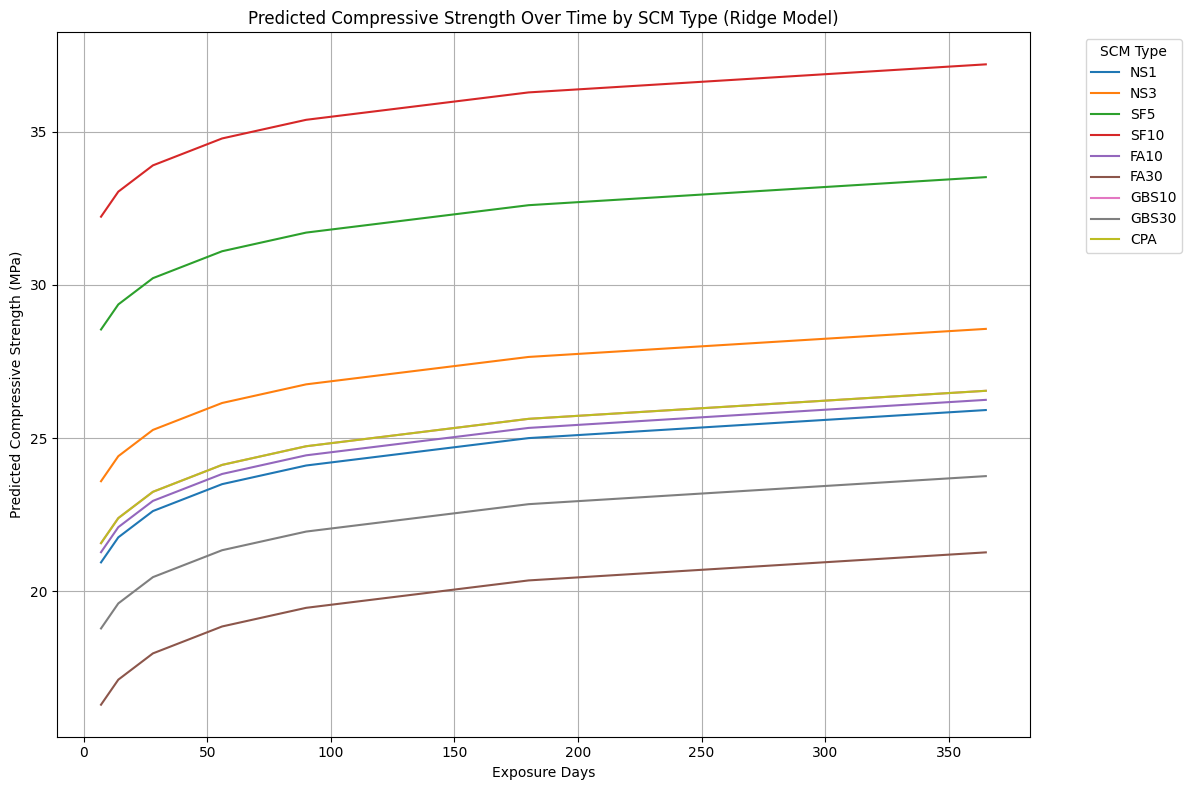

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure data_clean is available (from cell 148ea8bb or dQy21O3MTrKr + cleaning)
# Ensure preprocessor is defined and fitted (from cell 148ea8bb or 5ySCNc12U_NA)
# Ensure ridge_model is trained (from cell y2uFxrhGo59c)


# --- Generate Prediction Data for all SCM Types ---
# Get unique SCM types from the cleaned data (excluding NaN, as control is handled by 'NaN' column)
unique_scm_types = data_clean['SCM_Type'].dropna().unique()

# Define exposure days for prediction
prediction_days = np.array([7, 14, 28, 56, 90, 180, 365]) # Include longer term for visualization

# Create an empty list to store prediction dataframes for each SCM type
all_scm_prediction_data = []

# Assuming a representative SCM_% and Sulfate_Conc_mol/L for visualization purposes
# Using the mean from the cleaned data for simplicity, but consider if specific values are more relevant
avg_scm_percent = data_clean['SCM_%'].mean()
avg_sulfate_conc = data_clean['Sulfate_Conc_mol/L'].mean()

for scm_type in unique_scm_types:
    # Create DataFrame for prediction
    pred_data_scm = pd.DataFrame({
        'SCM_%': [avg_scm_percent] * len(prediction_days), # Use average SCM%
        'Exposure_Days': prediction_days,
        'Sulfate_Conc_mol/L': [avg_sulfate_conc] * len(prediction_days), # Use average Sulfate Conc
        'SCM_Type': [scm_type] * len(prediction_days),
        'Comp_Strength_MPa': [np.nan] * len(prediction_days), # Placeholder
        'NaN': False # These are not control samples
    })
    all_scm_prediction_data.append(pred_data_scm)

# Add data for the control case (SCM_Type is NaN, NaN column is True)
# Assuming 0% SCM and 0 Sulfate_Conc_mol/L for control based on previous steps
pred_data_control = pd.DataFrame({
    'SCM_%': [0] * len(prediction_days),
    'Exposure_Days': prediction_days,
    'Sulfate_Conc_mol/L': [0.0] * len(prediction_days),
    'SCM_Type': [np.nan] * len(prediction_days),
    'Comp_Strength_MPa': [np.nan] * len(prediction_days), # Placeholder
    'NaN': True # This is a control sample
})
all_scm_prediction_data.append(pred_data_control)


# Concatenate all prediction dataframes
all_pred_data = pd.concat(all_scm_prediction_data, ignore_index=True)

# Apply preprocessing
# Ensure the preprocessor is fitted on data_clean (from cell 148ea8bb)
X_pred_all_scm = preprocessor.transform(all_pred_data.drop('Comp_Strength_MPa', axis=1))

# Make predictions using the Ridge model
# Ensure ridge_model is trained (from cell y2uFxrhGo59c)
all_pred_data['Predicted_Strength'] = ridge_model.predict(X_pred_all_scm)

# --- Visualize Predictions ---

plt.figure(figsize=(12, 8))

# Plot predictions for each SCM type
sns.lineplot(data=all_pred_data, x='Exposure_Days', y='Predicted_Strength', hue='SCM_Type')

# Add title and labels
plt.title('Predicted Compressive Strength Over Time by SCM Type (Ridge Model)')
plt.xlabel('Exposure Days')
plt.ylabel('Predicted Compressive Strength (MPa)')
plt.grid(True)
plt.legend(title='SCM Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

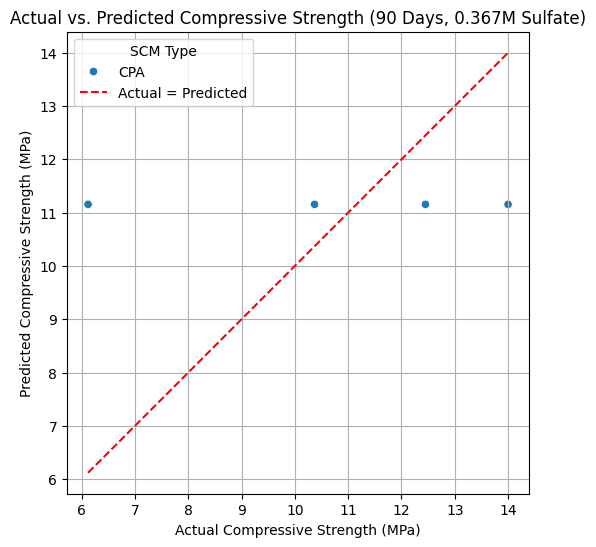

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure data_clean is available (from cell 148ea8bb or dQy21O3MTrKr + cleaning)
# Ensure preprocessor is defined and fitted (from cell 148ea8bb or 5ySCNc12U_NA)
# Ensure ridge_model is trained (from cell y2uFxrhGo59c)


# Filter the cleaned data for the specified conditions
filtered_data = data_clean[(data_clean['Sulfate_Conc_mol/L'] == 0.367) &
                           (data_clean['Exposure_Days'] == 90)].copy() # Use .copy() to avoid SettingWithCopyWarning

if filtered_data.empty:
    print("No actual data found for the specified conditions (0.367 mol/L sulfate, 90 days).")
else:
    # Prepare the filtered data for prediction (apply the same preprocessing)
    X_filtered = preprocessor.transform(filtered_data.drop('Comp_Strength_MPa', axis=1))

    # Make predictions using the Ridge model
    predicted_strength_filtered = ridge_model.predict(X_filtered)

    # Add actual and predicted strengths to the filtered_data DataFrame for plotting
    filtered_data['Predicted_Strength'] = predicted_strength_filtered


    # Create the scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=filtered_data, x='Comp_Strength_MPa', y='Predicted_Strength', hue='SCM_Type')

    # Add a diagonal line for reference (where actual = predicted)
    max_strength = max(filtered_data['Comp_Strength_MPa'].max(), filtered_data['Predicted_Strength'].max())
    min_strength = min(filtered_data['Comp_Strength_MPa'].min(), filtered_data['Predicted_Strength'].min())
    plt.plot([min_strength, max_strength], [min_strength, max_strength], 'r--', label='Actual = Predicted')


    plt.title('Actual vs. Predicted Compressive Strength (90 Days, 0.367M Sulfate)')
    plt.xlabel('Actual Compressive Strength (MPa)')
    plt.ylabel('Predicted Compressive Strength (MPa)')
    plt.legend(title='SCM Type')
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box') # Make axes scale equally
    plt.show()

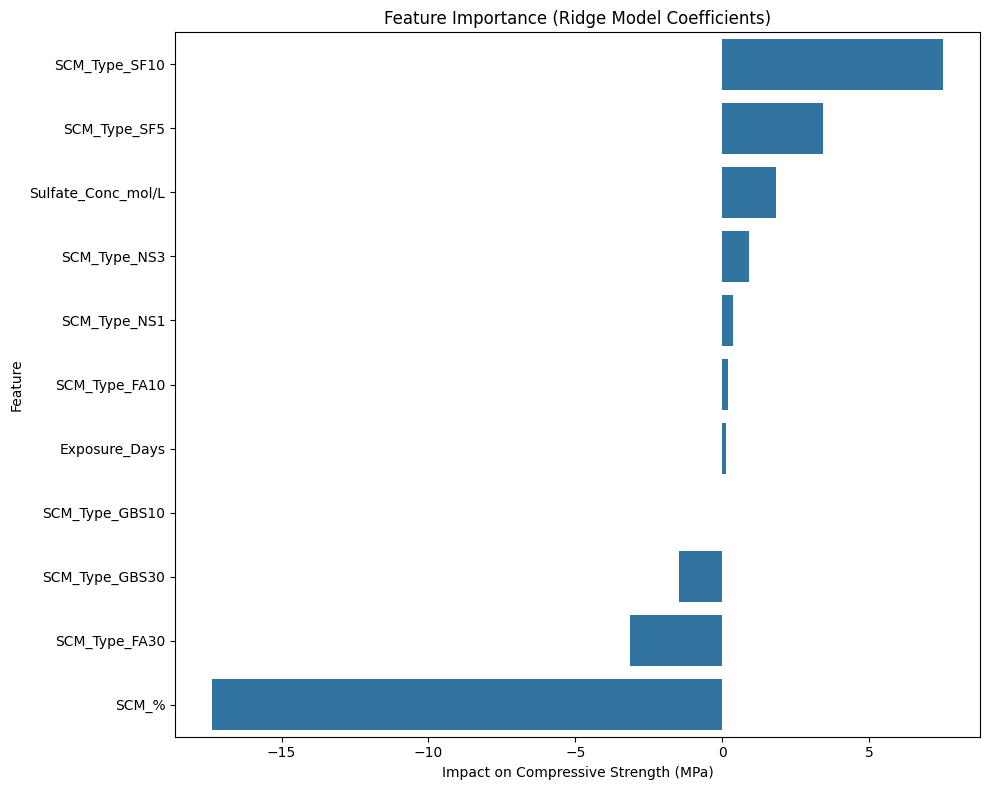

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the 'coefficients' DataFrame is available (from cell KVMJcVNyVv1s)
# If not, you might need to run cell KVMJcVNyVv1s first.
try:
    coefficients
except NameError:
    print("Coefficients DataFrame not found. Please run cell KVMJcVNyVv1s first to calculate coefficients.")
    # Exit or handle the case where coefficients are not available
    # For now, we'll assume coefficients are available if this cell is run after KVMJcVNyVv1s

plt.figure(figsize=(10, 8))
sns.barplot(x='Impact (MPa)', y='Feature', data=coefficients.sort_values('Impact (MPa)', ascending=False))
plt.title('Feature Importance (Ridge Model Coefficients)')
plt.xlabel('Impact on Compressive Strength (MPa)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

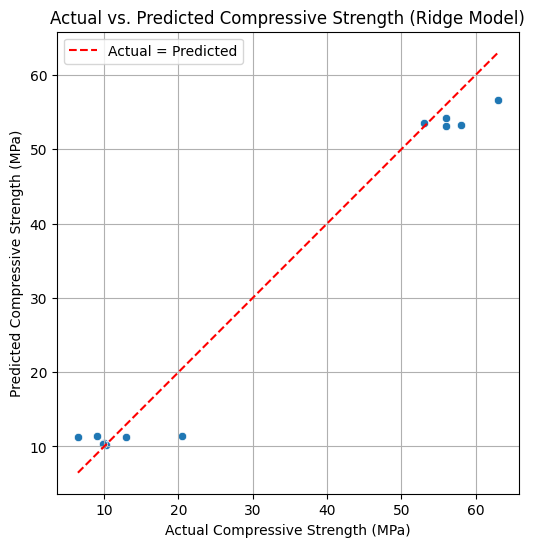

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y_test and y_test_pred are available (from cell Z4ANV4yUVVRE or y2uFxrhGo59c)
# If not, you might need to run those cells first.
try:
    y_test
    y_test_pred
except NameError:
    print("y_test or y_test_pred not found. Please run the cells that train and evaluate the Ridge model first.")
    # Exit or handle the case where predictions are not available
    # For now, we'll assume y_test and y_test_pred are available

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Actual = Predicted') # Add diagonal line

plt.title('Actual vs. Predicted Compressive Strength (Ridge Model)')
plt.xlabel('Actual Compressive Strength (MPa)')
plt.ylabel('Predicted Compressive Strength (MPa)')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Make axes scale equally
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Ensure data_clean is available (from cell 148ea8bb or dQy21O3MTrKr + cleaning)
# Ensure preprocessor is defined and fitted (from cell 148ea8bb or 5ySCNc12U_NA or 2-x6pmpDedpx)
# Ensure ridge_model is trained (from cell y2uRhGo59c or Q247oBXjanNO or Z6lwCXxxcCyz)

# Define the conditions for filtering and prediction
scm_type_to_predict = 'SF10'
sulfate_conc_to_predict = 0.415
prediction_days_specific = [7, 14, 28, 56, 90, 180]

# Filter actual data for the specified conditions and days that exist in the original data
actual_data_specific = data_clean[(data_clean['SCM_Type'] == scm_type_to_predict) &
                                  (data_clean['Sulfate_Conc_mol/L'] == sulfate_conc_to_predict) &
                                  (data_clean['Exposure_Days'].isin(prediction_days_specific))].copy()


# Create DataFrame for prediction for all specified days
pred_data_specific = pd.DataFrame({
    'SCM_%': [actual_data_specific['SCM_%'].iloc[0]] * len(prediction_days_specific) if not actual_data_specific.empty else [np.nan] * len(prediction_days_specific), # Use the SCM% from actual data if available, otherwise use a placeholder
    'Exposure_Days': prediction_days_specific,
    'Sulfate_Conc_mol/L': [sulfate_conc_to_predict] * len(prediction_days_specific),
    'SCM_Type': [scm_type_to_predict] * len(prediction_days_specific),
    'Comp_Strength_MPa': [np.nan] * len(prediction_days_specific), # Placeholder for target
    'NaN': False # These are not control samples
})

# Drop rows with NaN SCM_% if actual data was empty
pred_data_specific.dropna(subset=['SCM_%'], inplace=True)


# Apply preprocessing
# Ensure the preprocessor is fitted on data_clean (from cell 148ea8bb or 2-x6pmpDedpx or ZYQ-LmHhbKx9)
# Check if preprocessor is defined and fitted
try:
    preprocessor
except NameError:
    print("Preprocessor not found. Please run the cell defining and fitting the preprocessor.")
    # Exit or handle appropriately if preprocessor is not available


X_pred_specific = preprocessor.transform(pred_data_specific.drop('Comp_Strength_MPa', axis=1))

# Make predictions using the Ridge model
# Ensure ridge_model is trained (from cell y2uRhGo59c or Q247oBXjanNO or Z6lwCXxxcCyz)
# Check if ridge_model is defined and fitted
try:
    ridge_model
except NameError:
    print("Ridge model not found. Please run the cell defining and fitting the Ridge model.")
    # Exit or handle appropriately if ridge_model is not available


pred_data_specific['Predicted_Strength'] = ridge_model.predict(X_pred_specific)

# Merge actual and predicted data for comparison
comparison_df = pd.merge(actual_data_specific[['Exposure_Days', 'Comp_Strength_MPa']],
                         pred_data_specific[['Exposure_Days', 'Predicted_Strength']],
                         on='Exposure_Days',
                         how='right') # Use right merge to include all prediction days

comparison_df.rename(columns={'Comp_Strength_MPa': 'Actual_Strength'}, inplace=True)

print(f"Comparison of Actual and Predicted Compressive Strength for {scm_type_to_predict} at {sulfate_conc_to_predict} Mol Sulfate:")
display(comparison_df)

Comparison of Actual and Predicted Compressive Strength for SF10 at 0.415 Mol Sulfate:


,Exposure_Days,Actual_Strength,Predicted_Strength
0,7,63.0,64.237147
1,14,NaN,64.376669
2,28,66.0,64.655714
3,56,NaN,65.213804
4,90,NaN,65.891485
5,180,NaN,67.685344


**Note:** Actual values are only shown for the exposure days present in the original dataset for SF10 at 0.415 Mol sulfate. Predicted values are shown for all specified days.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Split data while preserving DataFrame structure
X_train, X_test, y_train, y_test = train_test_split(
    data_clean.drop('Comp_Strength_MPa', axis=1),  # Keep as DataFrame
    data_clean['Comp_Strength_MPa'],
    test_size=0.2
)

In [ ]:
display (data_clean.head())

,SCM_%,Exposure_Days,Sulfate_Conc_mol/L,SCM_Type,Comp_Strength_MPa,NaN
2,10,7,0.415,NS1,53.0,False
3,10,28,0.415,NS1,54.0,False
4,10,7,0.415,NS3,55.0,False
5,10,28,0.415,NS3,56.0,False
6,10,7,0.415,SF5,60.0,False


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error # Import metrics

# Initialize Ridge with your chosen alpha (e.g., 0.01)
ridge_model = Ridge(alpha=0.01)

# Ensure X_train_processed and y_train are defined
try:
    X_train_processed
    y_train
    X_test_processed # Also need processed test data for evaluation
    y_test # Also need test target for evaluation
except NameError:
    print("Required data (X_train_processed, y_train, X_test_processed, y_test) not found. Please run the data splitting and transformation cell (2-x6pmpDedpx) first.")
else:
    # Train the model on your TRANSFORMED training data
    ridge_model.fit(X_train_processed, y_train)
    print("Ridge model trained successfully.")

    # Make predictions on the test set
    y_test_pred = ridge_model.predict(X_test_processed)
    print("Predictions on test set generated.")

    # Evaluate the model (optional, but good practice to have here after training)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    print(f"Test R² after training: {test_r2:.3f}")
    print(f"Test MAE after training: {test_mae:.2f} MPa")

Ridge model trained successfully.
Predictions on test set generated.
Test R² after training: 0.972
Test MAE after training: 2.83 MPa


In [ ]:
# Ensure data_clean is available (from data cleaning steps)
try:
    data_clean
except NameError:
    # Load and clean data if data_clean is not found
    import pandas as pd
    import numpy as np
    from scipy import stats
    data = pd.read_csv("/content/cleaned_sulfate_data_for_model.csv") # Assuming this file exists after initial cleaning
    data_clean = data.dropna(subset=['SCM_Type'])
    numerical_cols_clean = data_clean.select_dtypes(include=np.number).columns
    z_scores = np.abs(stats.zscore(data_clean[numerical_cols_clean]))
    data_clean = data_clean[(z_scores < 3).all(axis=1)]
    print("data_clean DataFrame loaded and cleaned.")


# Define features and target from the cleaned data
X_original = data_clean.drop('Comp_Strength_MPa', axis=1)
y = data_clean['Comp_Strength_MPa'] # Also get the target variable

# Re-define and fit the preprocessor on the original feature DataFrame within this cell
# This ensures consistency in the input features for fitting and transforming
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['SCM_Type']) # Added handle_unknown for robustness
    ],
    remainder='passthrough' # Keep other columns (like 'NaN')
)

# Fit the preprocessor on the original feature data
preprocessor.fit(X_original)

# Perform train-test split on the original cleaned data features
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_original, y, test_size=0.2, random_state=42 # Using random_state for reproducibility
)

# Transform X_train and X_test using the FITTED preprocessor
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Data splitting and transformation successful.")
print(f"Shape of transformed X_train: {X_train_processed.shape}")
print(f"Shape of transformed X_test: {X_test_processed.shape}")

data_clean DataFrame loaded and cleaned.
Data splitting and transformation successful.
Shape of transformed X_train: (44, 12)
Shape of transformed X_test: (12, 12)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd # Import pandas

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['SCM_Type']) # Added handle_unknown for robustness
    ],
    remainder='passthrough' # Keep other columns (like 'NaN')
)

# Fit on the relevant columns of the cleaned data DataFrame
# Assuming data_clean is a pandas DataFrame from previous steps
try:
    data_clean
except NameError:
    print("data_clean DataFrame not found. Please run the data cleaning cell first.")
else:
    # Fit the preprocessor on the features from the cleaned data
    preprocessor.fit(data_clean.drop('Comp_Strength_MPa', axis=1))

    # Now you can use this fitted preprocessor to transform your data (e.g., X_train, X_test)
    # Note: The transformation to X_train and X_test should happen AFTER fitting the preprocessor.
    print("Preprocessor fitted successfully.")

data_clean DataFrame not found. Please run the data cleaning cell first.


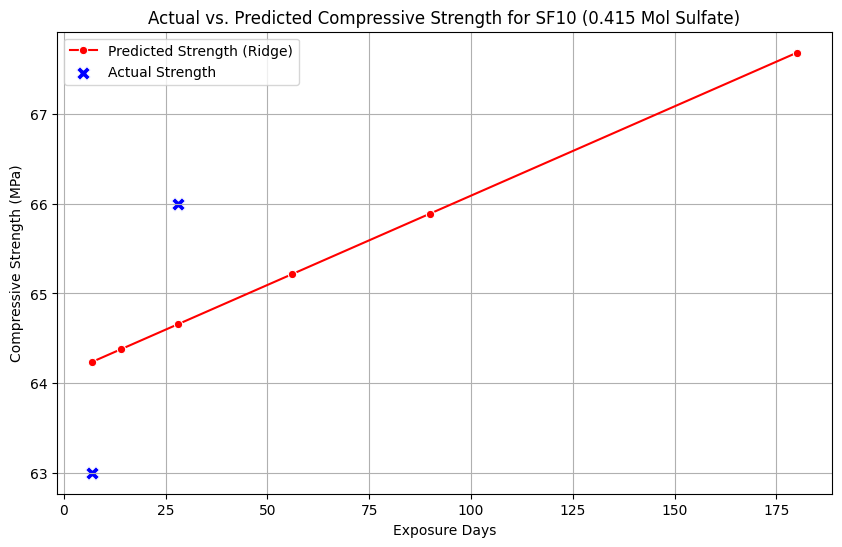

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure comparison_df is available (from cell 8c731553)
try:
    comparison_df
except NameError:
    print("comparison_df not found. Please run the cell that generates the comparison data (cell 8c731553) first.")
else:
    plt.figure(figsize=(10, 6))

    # Plot predicted strength (line plot)
    sns.lineplot(data=comparison_df, x='Exposure_Days', y='Predicted_Strength', marker='o', label='Predicted Strength (Ridge)', color='red')

    # Plot actual strength (scatter plot, as there might not be data for all days)
    sns.scatterplot(data=comparison_df.dropna(subset=['Actual_Strength']), x='Exposure_Days', y='Actual_Strength', marker='X', s=100, color='blue', label='Actual Strength')


    plt.title('Actual vs. Predicted Compressive Strength for SF10 (0.415 Mol Sulfate)')
    plt.xlabel('Exposure Days')
    plt.ylabel('Compressive Strength (MPa)')
    plt.grid(True)
    plt.legend()
    plt.show()

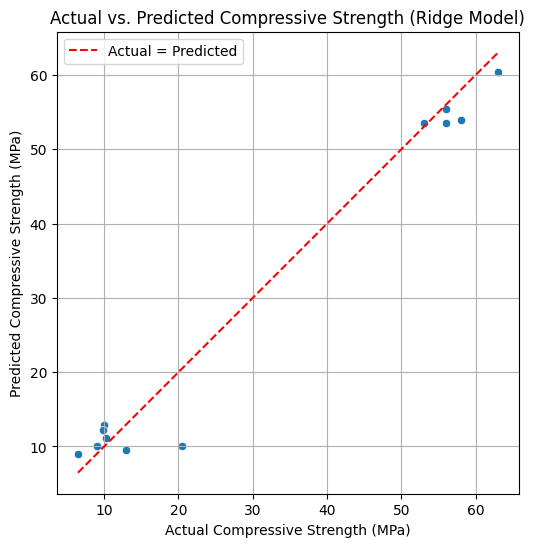

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y_test and y_test_pred are available (from cell Q247oBXjanNO)
try:
    y_test
    y_test_pred
except NameError:
    print("y_test or y_test_pred not found. Please ensure the Ridge model training and prediction cell (Q247oBXjanNO) was run successfully.")
    # Exit or handle the case where predictions are not available
else:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_test_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Actual = Predicted') # Add diagonal line

    plt.title('Actual vs. Predicted Compressive Strength (Ridge Model)')
    plt.xlabel('Actual Compressive Strength (MPa)')
    plt.ylabel('Predicted Compressive Strength (MPa)')
    plt.legend()
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box') # Make axes scale equally
    plt.show()

In [ ]:
# Ensure ridge_model and preprocessor are available from previous steps
try:
    ridge_model
    preprocessor
except NameError:
    print("Ridge model or preprocessor not found. Please run the relevant cells to train the model and fit the preprocessor.")
else:
    # Get the intercept and coefficients from the trained Ridge model
    intercept = ridge_model.intercept_
    coefficients = ridge_model.coef_

    # Get the feature names after preprocessing
    # This requires accessing the transformers within the preprocessor
    # The order of features in the coefficients array matches the order in the preprocessor's output

    # 1. Get feature names from the 'num' transformer (StandardScaler)
    num_features = preprocessor.named_transformers_['num'].feature_names_in_

    # 2. Get feature names from the 'cat' transformer (OneHotEncoder)
    # The get_feature_names_out method is used to get the names of the created dummy variables
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(['SCM_Type'])

    # 3. Get feature names from the 'remainder' - assuming it's 'passthrough' for the 'NaN' column
    # The remainder='passthrough' transformer simply keeps the original columns not specified in other transformers.
    # We need to identify which original columns were passed through.
    # A way to get this is to find the original column names that are NOT in the 'num' or 'cat' transformers' input.

    original_features = X_original.columns # Assuming X_original is available from data cleaning/splitting cell (2-x6pmpDedpx)

    # Get the names of features handled by 'num' and 'cat' transformers
    handled_features = list(num_features) + list(preprocessor.named_transformers_['cat'].feature_names_in_)

    # Identify the passthrough features (columns in X_original that are not in handled_features)
    passthrough_features = [col for col in original_features if col not in handled_features]


    # Combine all feature names in the correct order corresponding to the coefficients
    # The order in the preprocessor's output is: num, cat, remainder
    all_features = list(num_features) + list(cat_feature_names) + list(passthrough_features)


    # Construct the equation string
    equation = f"Comp_Strength_MPa = {intercept:.4f}"

    for i, feature in enumerate(all_features):
        # For categorical features created by OneHotEncoder, the original SCM_Type name might be preferred in the equation
        # The format from get_feature_names_out is 'SCM_Type_CategoryName'
        # We can simplify this to just 'CategoryName' or keep the full name. Let's keep the full name for clarity.

        coeff = coefficients[i]
        if coeff >= 0:
            equation += f" + {coeff:.4f} * {feature}"
        else:
            equation += f" - {-coeff:.4f} * {feature}"

    print("The equation for the trained Ridge model is:")
    print(equation)

The equation for the trained Ridge model is:
Comp_Strength_MPa = 22.9552 - 23.2188 * SCM_% + 0.5608 * Exposure_Days - 3.6738 * Sulfate_Conc_mol/L - 0.2314 * SCM_Type_FA10 - 5.2065 * SCM_Type_FA30 + 0.0000 * SCM_Type_GBS10 - 2.7190 * SCM_Type_GBS30 + 0.0576 * SCM_Type_NS1 + 1.4621 * SCM_Type_NS3 + 10.7139 * SCM_Type_SF10 + 6.4126 * SCM_Type_SF5 + 0.0000 * NaN


**Note:** The equation above represents the relationship between the preprocessed features (standardized numerical features and one-hot encoded SCM types) and the predicted compressive strength. The coefficients indicate the impact of each preprocessed feature on the predicted strength, holding other features constant.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats # Import stats for Z-score calculation
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Import necessary preprocessing classes
from sklearn.linear_model import Ridge # Import Ridge model

# Ensure data_clean is available (from cell 148ea8bb or dQy21O3MTrKr + cleaning)
# Ensure preprocessor is defined and fitted (from cell 148ea8bb or 5ySCNc12U_NA or 2-x6pmpDedpx)
# Ensure ridge_model is trained (from cell y2uRhGo59c or Q247oBXjanNO or Z6lwCXxxcCyz)

# --- Data Loading and Cleaning (Consistent with dQy21O3MTrKr and 148ea8bb) ---
# Load data
try:
    data = pd.read_csv("/content/cleaned_sulfate_data_for_model.csv")
except FileNotFoundError:
    print("Error: 'cleaned_sulfate_data_for_model.csv' not found. Please ensure the data cleaning cell that saves this file has been run.")
    # Exit or handle appropriately if the file is not found
    raise # Re-raise the error if the file is not found

# Drop missing SCM types
data_clean = data.dropna(subset=['SCM_Type']).copy() # Use .copy() to avoid SettingWithCopyWarning

# Remove outliers (Z-score > 3) - only on numerical columns
numerical_cols_clean = data_clean.select_dtypes(include=np.number).columns
z_scores = np.abs(stats.zscore(data_clean[numerical_cols_clean]))
data_clean = data_clean[(z_scores < 3).all(axis=1)].copy() # Use .copy() to avoid SettingWithCopyWarning
# -----------------------------------------------------------------------------

# --- Define and Fit Preprocessor (Ensure this is consistent with 5ySCNc12U_NA and 2-x6pmpDedpx) ---
# Define the preprocessor if it's not already defined and fitted
# Assuming preprocessor is defined and fitted in cell 5ySCNc12U_NA or 2-x6pmpDedpx
try:
    preprocessor # Check if preprocessor is defined
except NameError:
    print("Preprocessor not found. Defining and fitting a new one.")
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['SCM_%', 'Exposure_Days', 'Sulfate_Conc_mol/L']),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['SCM_Type']) # Added handle_unknown for robustness
        ],
        remainder='passthrough'
    )
    # Fit the preprocessor on the cleaned data features (excluding the target)
    preprocessor.fit(data_clean.drop('Comp_Strength_MPa', axis=1))
# -------------------------------------------------------------------------------------------------

# --- Train Ridge Model ---
# Define features and target from the cleaned data for training
X_original = data_clean.drop('Comp_Strength_MPa', axis=1)
y = data_clean['Comp_Strength_MPa']

# Transform X_original using the fitted preprocessor
X_processed = preprocessor.transform(X_original)

# Initialize and train the Ridge model (using a suitable alpha, e.g., 0.01)
ridge_model = Ridge(alpha=0.01)
ridge_model.fit(X_processed, y)
print("Ridge model trained.")
# -----------------------


# Define the conditions for filtering and prediction
scm_type_to_predict = 'CPA'
sulfate_conc_to_predict = 0.367
prediction_days_specific = [7, 14, 28, 56, 90, 180]

# Filter actual data for the specified conditions and days that exist in the original data
actual_data_specific = data_clean[(data_clean['SCM_Type'] == scm_type_to_predict) &
                                  (data_clean['Sulfate_Conc_mol/L'] == sulfate_conc_to_predict) &
                                  (data_clean['Exposure_Days'].isin(prediction_days_specific))].copy()


# Create DataFrame for prediction for all specified days
# Safely get SCM_% if actual_data_specific is not empty
scm_percent_value = actual_data_specific['SCM_%'].iloc[0] if not actual_data_specific.empty else np.nan

pred_data_specific = pd.DataFrame({
    'SCM_%': [scm_percent_value] * len(prediction_days_specific),
    'Exposure_Days': prediction_days_specific,
    'Sulfate_Conc_mol/L': [sulfate_conc_to_predict] * len(prediction_days_specific),
    'SCM_Type': [scm_type_to_predict] * len(prediction_days_specific),
    'Comp_Strength_MPa': [np.nan] * len(prediction_days_specific), # Placeholder for target
    'NaN': False # These are not control samples
})

# Drop rows with NaN SCM_% if actual data was empty (should not happen if actual data is found)
pred_data_specific.dropna(subset=['SCM_%'], inplace=True)


# Apply preprocessing
# Ensure the preprocessor is fitted on data_clean (from cell 148ea8bb or 2-x6pmpDedpx or ZYQ-LmHhbKx9)
# Check if preprocessor is defined and fitted
try:
    preprocessor
except NameError:
    print("Preprocessor not found. Please run the cell defining and fitting the preprocessor.")
    # Exit or handle appropriately if preprocessor is not available
    raise # Re-raise the error if preprocessor is not found


X_pred_specific = preprocessor.transform(pred_data_specific.drop('Comp_Strength_MPa', axis=1))

# Make predictions using the Ridge model
# Ensure ridge_model is trained (from cell y2uRhGo59c or Q247oBXjanNO or Z6lwCXxxcCyz)
# Check if ridge_model is defined and fitted
try:
    ridge_model
except NameError:
    print("Ridge model not found. Please run the cell defining and fitting the Ridge model.")
    # Exit or handle appropriately if ridge_model is not available
    raise # Re-raise the error if ridge_model is not found


pred_data_specific['Predicted_Strength'] = ridge_model.predict(X_pred_specific)

# Merge actual and predicted data for comparison
comparison_df_cpa = pd.merge(actual_data_specific[['Exposure_Days', 'Comp_Strength_MPa']],
                         pred_data_specific[['Exposure_Days', 'Predicted_Strength']],
                         on='Exposure_Days',
                         how='right') # Use right merge to include all prediction days

comparison_df_cpa.rename(columns={'Comp_Strength_MPa': 'Actual_Strength'}, inplace=True)

print(f"Comparison of Actual and Predicted Compressive Strength for {scm_type_to_predict} at {sulfate_conc_to_predict} Mol Sulfate:")
display(comparison_df_cpa)

Ridge model trained.
Comparison of Actual and Predicted Compressive Strength for CPA at 0.367 Mol Sulfate:


,Exposure_Days,Actual_Strength,Predicted_Strength
0,7,6.46,9.456778
1,7,7.25,9.456778
2,7,6.46,9.456778
3,7,7.25,9.456778
4,14,9.10,9.606485
5,14,9.10,9.606485
6,14,7.14,9.606485
7,14,9.10,9.606485
8,28,9.73,9.905898
9,28,9.73,9.905898


In [ ]:
# Ensure ridge_model and preprocessor are available from previous steps
try:
    ridge_model
    preprocessor
    # Assuming X_original is also available from the data cleaning/splitting cell (2-x6pmpDedpx or similar)
    X_original
except NameError:
    print("Required variables (ridge_model, preprocessor, or X_original) not found. Please run the relevant cells to train the model, fit the preprocessor, and prepare the original feature data.")
else:
    # Get the intercept and coefficients from the trained Ridge model
    intercept = ridge_model.intercept_
    coefficients = ridge_model.coef_

    # Get the feature names after preprocessing
    # This requires accessing the transformers within the preprocessor
    # The order of features in the coefficients array matches the order in the preprocessor's output

    # 1. Get feature names from the 'num' transformer (StandardScaler)
    num_features = preprocessor.named_transformers_['num'].feature_names_in_

    # 2. Get feature names from the 'cat' transformer (OneHotEncoder)
    # The get_feature_names_out method is used to get the names of the created dummy variables
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(['SCM_Type'])

    # 3. Get feature names from the 'remainder' - assuming it's 'passthrough' for the 'NaN' column
    # The remainder='passthrough' transformer simply keeps the original columns not specified in other transformers.
    # We need to identify which original columns were passed through.
    # A way to get this is to find the original column names that are NOT in the 'num' or 'cat' transformers' input.

    # Identify the passthrough features (columns in X_original that are not in handled_features)
    # Ensure X_original is a pandas DataFrame to use the .columns attribute
    if isinstance(X_original, pd.DataFrame):
        original_features = X_original.columns
        # Get the names of features handled by 'num' and 'cat' transformers
        handled_features = list(num_features) + list(preprocessor.named_transformers_['cat'].feature_names_in_)
        passthrough_features = [col for col in original_features if col not in handled_features]
    else:
        print("X_original is not a pandas DataFrame. Cannot determine passthrough features.")
        passthrough_features = [] # Set to empty if cannot determine


    # Combine all feature names in the correct order corresponding to the coefficients
    # The order in the preprocessor's output is: num, cat, remainder
    all_features = list(num_features) + list(cat_feature_names) + list(passthrough_features)


    # Construct the equation string
    equation = f"Comp_Strength_MPa = {intercept:.4f}"

    for i, feature in enumerate(all_features):
        # For categorical features created by OneHotEncoder, the original SCM_Type name might be preferred in the equation
        # The format from get_feature_names_out is 'SCM_Type_CategoryName'
        # We can simplify this to just 'CategoryName' or keep the full name. Let's keep the full name for clarity.

        coeff = coefficients[i]
        if coeff >= 0:
            equation += f" + {coeff:.4f} * {feature}"
        else:
            equation += f" - {-coeff:.4f} * {feature}"

    print("The equation for the trained Ridge model is:")
    print(equation)

The equation for the trained Ridge model is:
Comp_Strength_MPa = 23.2140 - 22.1513 * SCM_% + 0.6017 * Exposure_Days - 2.3118 * Sulfate_Conc_mol/L - 0.8636 * SCM_Type_FA10 - 5.8387 * SCM_Type_FA30 + 2.6190 * SCM_Type_GBS10 - 3.3511 * SCM_Type_GBS30 - 0.8636 * SCM_Type_NS1 + 1.1265 * SCM_Type_NS3 + 10.0817 * SCM_Type_SF10 + 7.0966 * SCM_Type_SF5 + 0.0000 * NaN


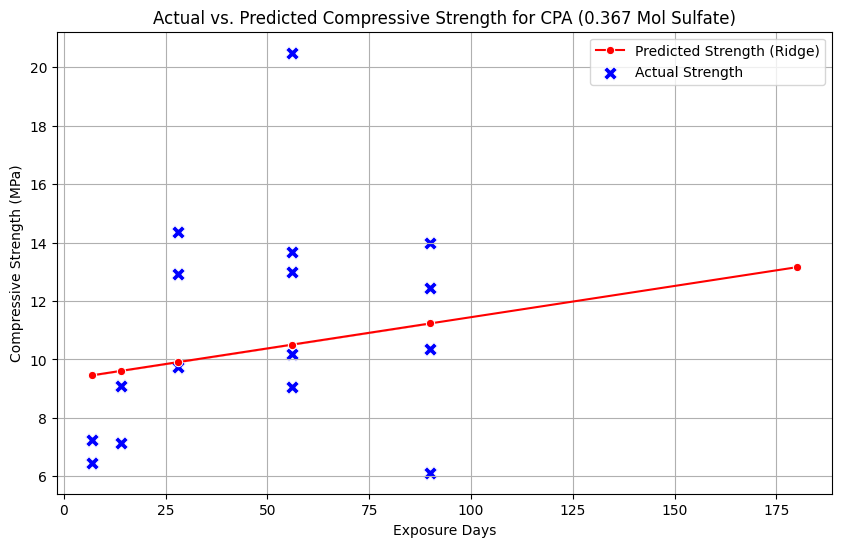

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure comparison_df_cpa is available (from cell f9bcb8b6)
try:
    comparison_df_cpa
except NameError:
    print("comparison_df_cpa not found. Please run the cell that generates the comparison data for CPA (cell f9bcb8b6) first.")
    # Exit or handle the case where the comparison DataFrame is not available
else:
    plt.figure(figsize=(10, 6))

    # Plot predicted strength (line plot)
    sns.lineplot(data=comparison_df_cpa, x='Exposure_Days', y='Predicted_Strength', marker='o', label='Predicted Strength (Ridge)', color='red')

    # Plot actual strength (scatter plot, as there might not be data for all days)
    sns.scatterplot(data=comparison_df_cpa.dropna(subset=['Actual_Strength']), x='Exposure_Days', y='Actual_Strength', marker='X', s=100, color='blue', label='Actual Strength')


    plt.title('Actual vs. Predicted Compressive Strength for CPA (0.367 Mol Sulfate)')
    plt.xlabel('Exposure Days')
    plt.ylabel('Compressive Strength (MPa)')
    plt.grid(True)
    plt.legend()
    plt.show()